<center>
    <h1>Moneyball for Murderball: Using analytics to construct lineups in wheelchair rugby</h1>
    <h2>Data Wrangling in Practice</h2>
    <h3>Real-world data cleaning, parsing, joining, visualizing</h3>
    <hr>
</center>

<center>
    <h2>Descriptive analytics Part</h2>
    <hr>
</center>

In [1]:
# Import packages
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from scipy import stats

# Import stint and player data
stint_data = pd.read_csv("stint_data.csv")
player_data = pd.read_csv("player_data.csv")

---

## **Question 1**
##### Explore the data to 
##### a) compute the total number of stints in the dataset, 
##### b) compute the total number of stints for each country that competed against Canada, 
##### c) create a histogram to show the distribution of player physical ratings in the dataset, and 
##### d) create a histogram to show the distribution of player physical ratings in Team Canada

---

Total number of stints: 7448
             team  num_stints
2          Canada        1263
9          Poland         123
6          France         121
10         Sweden         118
7   Great.Britain         117
8           Japan         117
5         Denmark         115
0       Argentina         112
4        Columbia         112
11            USA         112
1          Brazil         110
3           Chile         106


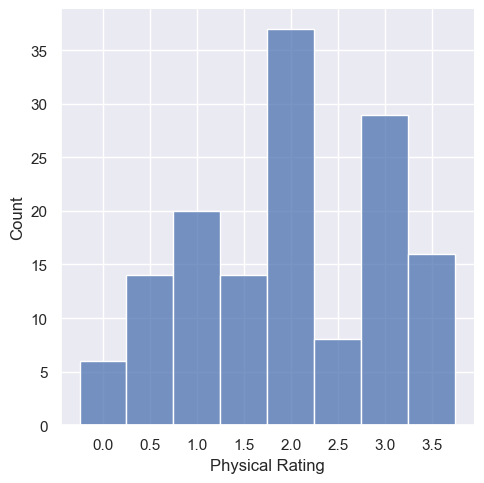

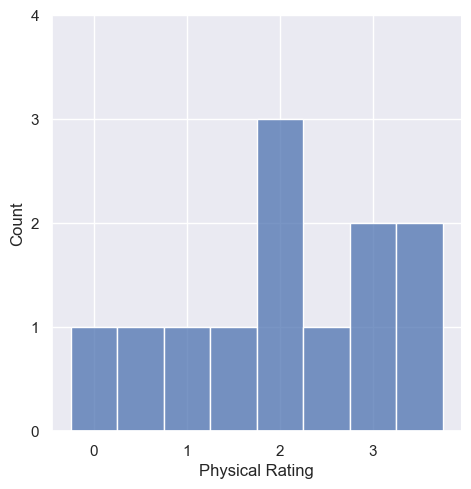

In [5]:
# a)
# Count rows
print("Total number of stints:", len(stint_data.index))

# b)
# Create new dataframe to record number of stints, then get unique teams
stints_count = pd.DataFrame(columns=["team", "num_stints"])
stints_count["team"] = list(sorted(set(stint_data['h_team'].tolist() + stint_data['a_team'].tolist())))
stints_count["num_stints"] = 0

# Iterate through each stint that Canada has played in and record the countries
for stint in stint_data.itertuples():
    if ('Canada' in stint.h_team) or ('Canada' in stint.a_team):
        # Sum up the stints for each country over all games
        stints_count.loc[stints_count["team"] == stint.h_team, "num_stints"] += 1
        stints_count.loc[stints_count["team"] == stint.a_team, "num_stints"] += 1
stints_count.sort_values(by="num_stints", ascending=False, inplace=True)
print(stints_count)

# c)
# Manually set the bins for each player rating
hist = sns.displot(player_data, x="rating", bins=[-0.25, 0.25, 0.75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75])
plt.xlabel("Physical Rating")
plt.show()
hist.savefig("rating_hist" + ".png")
plt.close()

# d)
# Create a new column in the player dataset that records the athlete’s country by parsing the “player” column
player_data["team"] = player_data["player"].str.split('_').str[0]

# Plot only Canadian athletes 
hist = sns.displot(player_data[player_data["team"].str.contains('Canada')], x="rating", bins=[-0.25, 0.25, 0.75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75])
hist.set(yticks=[0, 1, 2, 3, 4])
plt.xlabel("Physical Rating")
plt.show()
hist.savefig("rating_hist_Canada" + ".png")
plt.close()

---

## **Question 2**
##### What is the 
##### a) average number of goals scored per game, and 
##### b) average margin of victory per game?

---

In [6]:
# a)
# Group by game, add home and away goals, then take avg
goals_pg = stint_data.groupby(['game_id'])[["h_goals", "a_goals"]].sum()
print(goals_pg)
avg_goals_pg = np.mean([goals_pg.loc[game,"h_goals"] + goals_pg.loc[game,"a_goals"] for game in goals_pg.index])
print("Average goals per game:", avg_goals_pg)

# b)
# Group by game, take absolute difference between home and away goals, then take avg
avg_victory_pg = np.mean([abs(goals_pg.loc[game,"h_goals"] - goals_pg.loc[game,"a_goals"]) for game in goals_pg.index])
print("Average margin of victory per game:", avg_victory_pg)

         h_goals  a_goals
game_id                  
1             42       63
2             45       42
3             46       28
4             52       33
5             41       53
...          ...      ...
656           63       51
657           52       67
658           54       55
659           51       61
660           53       59

[660 rows x 2 columns]
Average goals per game: 98.71969696969697
Average margin of victory per game: 14.274242424242424


---

## **Question 3**
##### For each team, what is their 
##### a) win/loss record, and 
##### b) the average plus-minus per game?

---

In [7]:
# Create new dataframe to record win/loss, get unique teams
team_record = pd.DataFrame(columns=["team", "win", "loss", "games", "total_plus_minus", "avg_plus_minus"])
team_record["team"] = list(sorted(list(set(list(stint_data["h_team"].unique()) + list(stint_data["a_team"].unique())))))
team_record[["win", "loss", "games", "total_plus_minus"]] = 0

# Group by {game, home team, away team}, determine win/loss and plus-minus from home and away goals
goals_pg = stint_data.groupby(['game_id', 'h_team', 'a_team'])[["h_goals", "a_goals"]].sum()
print(goals_pg)
for game in goals_pg.index:
    team_record.loc[team_record["team"] == game[1], "games"] += 1
    team_record.loc[team_record["team"] == game[2], "games"] += 1
    # a)
    if goals_pg.loc[game, "h_goals"] > goals_pg.loc[game, "a_goals"]:
        team_record.loc[team_record["team"] == game[1], "win"] += 1
        team_record.loc[team_record["team"] == game[2], "loss"] += 1
    elif goals_pg.loc[game, "h_goals"] < goals_pg.loc[game, "a_goals"]:
        team_record.loc[team_record["team"] == game[2], "win"] += 1
        team_record.loc[team_record["team"] == game[1], "loss"] += 1
    # b)
    team_record.loc[team_record["team"] == game[1], "total_plus_minus"] += goals_pg.loc[game, "h_goals"] - goals_pg.loc[game, "a_goals"]
    team_record.loc[team_record["team"] == game[2], "total_plus_minus"] += goals_pg.loc[game, "a_goals"] - goals_pg.loc[game, "h_goals"]
team_record["avg_plus_minus"] = team_record["total_plus_minus"] / team_record["games"]
        
print("Team record and average plus-minus per game:")
print(team_record.sort_values(['win','avg_plus_minus'], ascending=False))

                              h_goals  a_goals
game_id h_team a_team                         
1       USA    Japan               42       63
2       USA    Great.Britain       45       42
3       USA    Canada              46       28
4       USA    France              52       33
5       USA    Denmark             41       53
...                               ...      ...
656     Chile  Sweden              63       51
657     Chile  Brazil              52       67
658     Chile  Columbia            54       55
659     Chile  Poland              51       61
660     Chile  Argentina           53       59

[660 rows x 2 columns]
Team record and average plus-minus per game:
             team  win  loss  games  total_plus_minus  avg_plus_minus
8           Japan   91    19    110              1595       14.500000
11            USA   78    32    110              1138       10.345455
2          Canada   77    33    110               822        7.472727
6          France   70    40    110     

---

## **Question 4**
##### Does the home team win more often? If so, how much more often?

---

In [8]:
home_wins = 0
away_wins = 0
# Group by game, determine win/loss from home and away goals
goals_pg = stint_data.groupby(['game_id'])[["h_goals", "a_goals"]].sum()
print(goals_pg)
for game in goals_pg.index:
    if goals_pg.loc[game, "h_goals"] > goals_pg.loc[game, "a_goals"]:
        home_wins += 1
    elif goals_pg.loc[game, "h_goals"] < goals_pg.loc[game, "a_goals"]:
        away_wins += 1

print("Number of home wins:", home_wins)
print("Number of away wins:", away_wins)
print("How often does the home team win:", home_wins/(home_wins+away_wins))

         h_goals  a_goals
game_id                  
1             42       63
2             45       42
3             46       28
4             52       33
5             41       53
...          ...      ...
656           63       51
657           52       67
658           54       55
659           51       61
660           53       59

[660 rows x 2 columns]
Number of home wins: 375
Number of away wins: 285
How often does the home team win: 0.5681818181818182


---

## **Question 5**
##### What is the plus-minus per minute for each athlete? Identify the best athlete from each team according to their plus-minus per minute.

---

In [10]:
# Iterate through each stint and assign the plus-minus and minutes played to each athlete that played
stint_data["h_plus_minus"] = stint_data["h_goals"] - stint_data["a_goals"]
stint_data["a_plus_minus"] = -1*stint_data["h_plus_minus"]
player_data["minutes"] = 0
player_data["plus_minus"] = 0
player_cols = ["home1", "home2", "home3", "home4", "away1", "away2", "away3", "away4"]
for stint in stint_data.itertuples():
    for player in player_cols:
        player_data.loc[player_data["player"] == getattr(stint, player), "minutes"] += stint.minutes
        if player[0] == "h":
            player_data.loc[player_data["player"] == getattr(stint, player), "plus_minus"] += stint.h_plus_minus
        elif player[0] == "a":
            player_data.loc[player_data["player"] == getattr(stint, player), "plus_minus"] += stint.a_plus_minus
player_data["plus_minus_per_minute"] = player_data["plus_minus"] / player_data["minutes"]

# Get each athlete's team
player_data["team"] = player_data["player"].str.split('_').str[0]

# Print all athletes
pd.set_option('display.max_rows', len(player_data))
print(player_data)
pd.reset_option('display.max_rows')

# Get best athlete from each team by sorting by plus_minus_per_minute and dropping duplicate teams
print("Athlete plus-minus per minute:")
pd.set_option('expand_frame_repr', False)
print(player_data[['player', 'rating', 'minutes', 'plus_minus', 'plus_minus_per_minute', 'team']].sort_values('plus_minus_per_minute', ascending=False).drop_duplicates(['team']))

                player  rating           team      minutes  plus_minus  \
0               USA_p1     3.0            USA  1155.774143         458   
1               USA_p2     3.0            USA  1067.953325          65   
2               USA_p3     3.5            USA   888.478357         265   
3               USA_p4     0.0            USA  1421.401843          94   
4               USA_p5     2.0            USA  1039.289768         250   
5               USA_p6     0.5            USA  1371.410543         614   
6               USA_p7     1.5            USA  1365.531145         716   
7               USA_p8     2.5            USA  1189.860930         639   
8               USA_p9     1.0            USA  1350.456526         619   
9              USA_p10     1.0            USA  1306.934827         233   
10             USA_p11     3.5            USA   899.800906         218   
11             USA_p12     3.0            USA  1047.107687         381   
12            Japan_p1     1.0        

---

## **Question 6**
##### Is there a correlation between an athlete’s performance and their physical rating?

---

(Correlation coefficient, p-value) between athlete rating and their plus-minus per minute: PearsonRResult(statistic=0.08601311697275925, pvalue=0.30533355004832463)


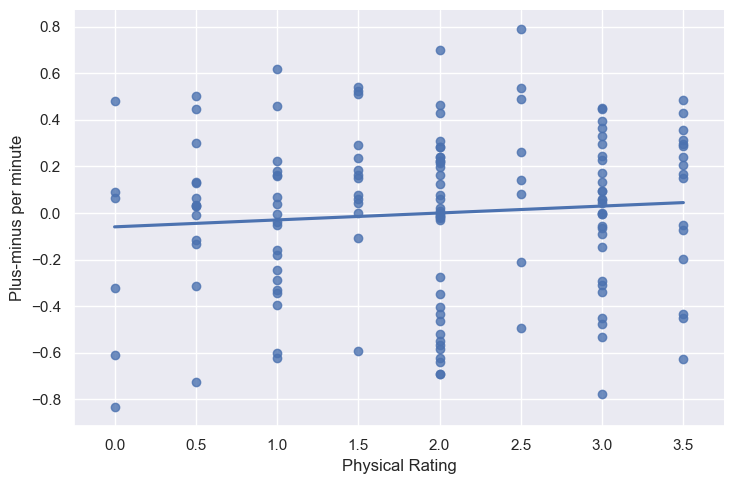

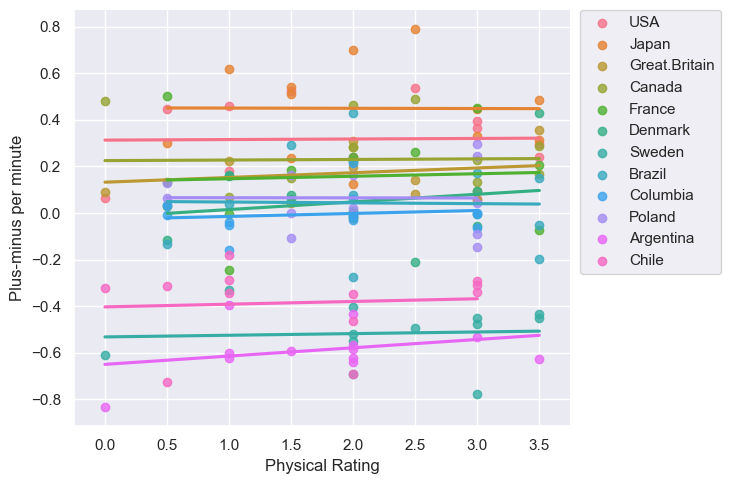

In [11]:
# Import the data worked on in the previous questions
#player_data = pd.read_excel(data_location + "\\player.xlsx")
print("(Correlation coefficient, p-value) between athlete rating and their plus-minus per minute:", stats.pearsonr(player_data['rating'], player_data['plus_minus_per_minute']))

# Plot plus-minus per minute vs. rating (scatter)

# All teams
scatter = sns.lmplot(x="rating", y="plus_minus_per_minute", data=player_data, ci=None, legend=False, aspect=1.5, truncate=True)
scatter.set(xlim=(-0.25, 3.75))
# Set title
#plt.title("Plus-minus per minute vs. rating")
# Set x-axis label
plt.xlabel("Physical Rating")
# Set y-axis label
plt.ylabel("Plus-minus per minute")

plt.tight_layout()
plt.show()
scatter.savefig("ath_rating" + ".png")
plt.close()

# Grouped by team
scatter = sns.lmplot(x="rating", y="plus_minus_per_minute", hue="team", data=player_data, ci=None, legend=False, aspect=1.5, truncate=True)
plt.legend(bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0.)
scatter.set(xlim=(-0.25, 3.75))
# Set title
#plt.title("Plus-minus per minute vs. rating, grouped by team")
# Set x-axis label
plt.xlabel("Physical Rating")
# Set y-axis label
plt.ylabel("Plus-minus per minute")

plt.tight_layout()
plt.show()
scatter.savefig("ath_rating_team" + ".png")
plt.close()

---

## **Question 7**
##### Is there a correlation between plus-minus and the sum of the athlete physical ratings in a lineup?

---

In [12]:
# Get home and away ratings and lineups for each stint in stint data
stint_data[["h_lineup", "a_lineup", "h_r1", "h_r2", "h_r3", "h_r4", "a_r1", "a_r2", "a_r3", "a_r4", "h_lineup_type", "a_lineup_type", "h_lineup_sum", "a_lineup_sum"]] = -1
player_cols = ["home1", "home2", "home3", "home4", "away1", "away2", "away3", "away4"]
rating_cols = ["h_r1", "h_r2", "h_r3", "h_r4", "a_r1", "a_r2", "a_r3", "a_r4"]

# For each stint, record the lineup and ratings
for stint in stint_data.itertuples():
    # Get lineups by sorting and joining players
    h_players = [stint_data.loc[getattr(stint, "Index"), player] for player in player_cols if player[:4] == "home"]
    a_players = [stint_data.loc[getattr(stint, "Index"), player] for player in player_cols if player[:4] == "away"]
    stint_data.loc[getattr(stint, "Index"), "h_lineup"] = "-".join(list(sorted([str(player) for player in h_players])))
    stint_data.loc[getattr(stint, "Index"), "a_lineup"] = "-".join(list(sorted([str(player) for player in a_players])))
    
    # Get ratings
    for player, rating in zip(player_cols, rating_cols):
        stint_data.loc[getattr(stint, "Index"), rating] = player_data.loc[player_data["player"] == getattr(stint, player), "rating"].values
    
    h_ratings = [stint_data.loc[getattr(stint, "Index"), rating] for rating in rating_cols if rating[:3] == "h_r"]
    a_ratings = [stint_data.loc[getattr(stint, "Index"), rating] for rating in rating_cols if rating[:3] == "a_r"]
    stint_data.loc[getattr(stint, "Index"), "h_lineup_type"] = "-".join(list(sorted([str(rating) for rating in h_ratings], reverse=True)))
    stint_data.loc[getattr(stint, "Index"), "a_lineup_type"] = "-".join(list(sorted([str(rating) for rating in a_ratings], reverse=True)))
    stint_data.loc[getattr(stint, "Index"), "h_lineup_sum"] = sum(h_ratings)
    stint_data.loc[getattr(stint, "Index"), "a_lineup_sum"] = sum(a_ratings)
        
# Create lineup table
cols = ["game_id", "team", "lineup", "lineup_type", "lineup_sum", "minutes", "goals_for", "goals_against", "plus_minus", "home_away"]

# Separate home and away to get two lineups for each stint, then combine into one table
h_lineup_data = stint_data[["game_id", "h_team", "h_lineup", "h_lineup_type", "h_lineup_sum", "minutes", "h_goals", "a_goals", "h_plus_minus"]]
h_lineup_data["home_away"] = "home"
new_cols = {x: y for x, y in zip(h_lineup_data.columns, cols)}
h_lineup_data.rename(columns=new_cols, inplace=True)

a_lineup_data = stint_data[["game_id", "a_team", "a_lineup", "a_lineup_type", "a_lineup_sum", "minutes", "a_goals", "h_goals", "a_plus_minus"]]
a_lineup_data["home_away"] = "away"
new_cols = {x: y for x, y in zip(a_lineup_data.columns, cols)}
a_lineup_data.rename(columns=new_cols, inplace=True)

lineup_data = pd.concat([h_lineup_data, a_lineup_data], ignore_index=True, sort=False)

C:\Users\pz6755\AppData\Local\Temp\ipykernel_23340\1487255662.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  h_lineup_data["home_away"] = "home"
C:\Users\pz6755\AppData\Local\Temp\ipykernel_23340\1487255662.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  h_lineup_data.rename(columns=new_cols, inplace=True)
C:\Users\pz6755\AppData\Local\Temp\ipykernel_23340\1487255662.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documenta

In [13]:
lineup_data

,game_id,team,lineup,lineup_type,lineup_sum,minutes,goals_for,goals_against,plus_minus,home_away
0,1,USA,USA_p1-USA_p3-USA_p4-USA_p6,3.5-3-0.5-0,7.0,4.252969,4,9,-5,home
1,1,USA,USA_p1-USA_p5-USA_p6-USA_p7,3-2.0-1.5-0.5,7.0,5.688809,6,11,-5,home
2,1,USA,USA_p1-USA_p4-USA_p5-USA_p8,3.0-2.5-2.0-0.0,7.5,1.149557,0,1,-1,home
3,1,USA,USA_p2-USA_p6-USA_p7-USA_p8,3.0-2.5-1.5-0.5,7.5,3.511617,7,5,2,home
4,1,USA,USA_p5-USA_p7-USA_p8-USA_p9,2.5-2.0-1.5-1.0,7.0,2.163139,7,5,2,home
...,...,...,...,...,...,...,...,...,...,...
14891,660,Argentina,Argentina_p1-Argentina_p10-Argentina_p12-Argen...,3.0-2.0-1.5-1.0,7.5,2.583097,2,6,-4,away
14892,660,Argentina,Argentina_p10-Argentina_p11-Argentina_p3-Argen...,3.0-2.0-2.0-1.0,8.0,1.039052,3,4,-1,away
14893,660,Argentina,Argentina_p1-Argentina_p2-Argentina_p3-Argenti...,3.5-2.0-1.5-1.0,8.0,1.599023,0,3,-3,away
14894,660,Argentina,Argentina_p10-Argentina_p3-Argentina_p8-Argent...,3.0-2.0-2.0-1.0,8.0,3.841087,13,6,7,away


(Correlation coefficient, p-value) between lineup sum and their plus-minus per minute: (0.16748381411580893, 1.0834245443258585e-12)


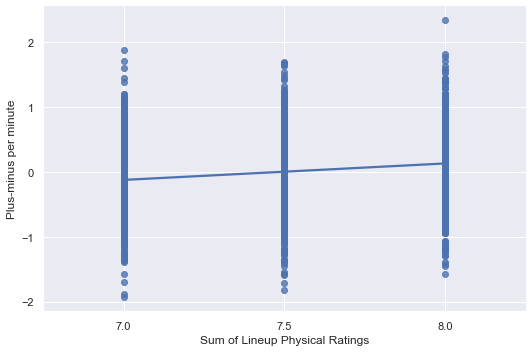

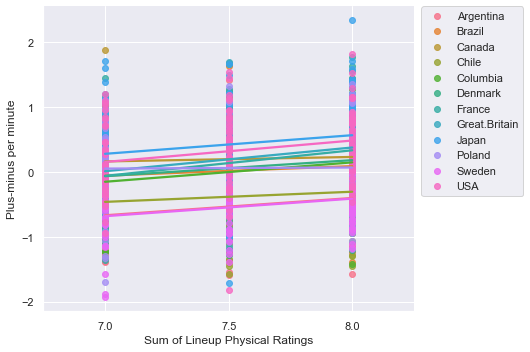

In [9]:
# Group by lineup -- new columns will be [game_id, lineup_sum, minutes, goals_for, goals_against, plus_minus]
lineup_groupby_data = lineup_data.groupby(['lineup'], as_index=False).sum()
# Drop game_id
lineup_groupby_data.drop(columns=['game_id', 'lineup_sum'], inplace=True)

# Re-calculate lineup_sum and plus_minus_per_minute, and create individual player and team columns
for lineup in lineup_groupby_data.itertuples():
    players = lineup_groupby_data.loc[getattr(lineup, "Index"), "lineup"].split("-")
    lineup_groupby_data.loc[getattr(lineup, "Index"), "lineup_sum"] = sum([player_data.loc[player_data['player'] == player, 'rating'].values for player in players])
    lineup_groupby_data.loc[getattr(lineup, "Index"), "team"] = players[0].split("_")[0]
    for i, player in enumerate(players):
        player_col = "p" + str(i+1)
        lineup_groupby_data.loc[getattr(lineup, "Index"), player_col] = players[i]
lineup_groupby_data.loc[:, "plus_minus_per_minute"] = lineup_groupby_data.loc[:, "plus_minus"] / lineup_groupby_data.loc[:, "minutes"]

# Plot for all teams
print("(Correlation coefficient, p-value) between lineup sum and their plus-minus per minute:", stats.pearsonr(lineup_groupby_data["lineup_sum"], lineup_groupby_data["plus_minus_per_minute"]))
scatter = sns.lmplot(x="lineup_sum", y="plus_minus_per_minute", data=lineup_groupby_data, ci=None, legend=False, aspect=1.5, truncate=True)
scatter.set(xticks = [7.0, 7.5, 8.0], xlim=(6.75, 8.25))

# Set title
#plt.title("Plus-minus per minute vs. Lineup Sum")
# Set x-axis label
plt.xlabel("Sum of Lineup Physical Ratings")
# Set y-axis label
plt.ylabel("Plus-minus per minute")

plt.tight_layout()
plt.show()
scatter.savefig(data_location + "\\Plots\\" + "lineup_sum" + ".png")
plt.close()

# Plot grouped by team
scatter = sns.lmplot(x="lineup_sum", y="plus_minus_per_minute", hue="team", data=lineup_groupby_data, ci=None, legend=False, aspect=1.5, truncate=True)
scatter.set(xticks = [7.0, 7.5, 8.0], xlim=(6.75, 8.25))
plt.legend(bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0.)

# Set title
#plt.title("Plus-minus per minute vs. Lineup Sum, grouped by team")
# Set x-axis label
plt.xlabel("Sum of Lineup Physical Ratings")
# Set y-axis label
plt.ylabel("Plus-minus per minute")

plt.tight_layout()
plt.show()
scatter.savefig(data_location + "\\Plots\\" + "lineup_sum_team" + ".png")
plt.close()